# S-inhibition emergence — full sweep (40 cells × 4 Pythia sizes)

Goldowsky-Dill 2023 path-patching detector with frozen paths across Pythia-70m, 160m, 410m, 1b; locked threshold τ_strict = 0.0372 (§S-tau); 40 log-spaced checkpoints per §H2-1; prompt-bootstrap CIs on μ per §H2-2.

**Locked thresholds:**
- Detection threshold: Δ_h ≥ τ_strict = 0.0372 (§S-tau).
- Bootstrap: per-prompt resampling, B = 1000, 95% percentile CI.
- Tiered fit handling: emerged (max ≥ 5), marginal (2-4), censored (max < 2).

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long
from src.analysis.phase2_logistic import tiered_fit, RIGHT_CENSOR_STEP
from src.analysis.phase2_bootstrap import (
    bootstrap_s_inhibition, summarize_bootstrap, THRESHOLD_SENSITIVITY_FRACTIONS,
)

SIZES = ['70m', '160m', '410m', '1b']
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green', '1b': 'tab:red'}
TAU_STRICT = 0.0372

def sweep_path(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_s_inhibition_sweep.parquet'
    return REPO / 'data' / 'exploration' / 'phase2_s_inhibition_sweep.parquet'

def per_prompt_dir(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_s_inhibition_per_prompt'
    return REPO / 'data' / 'exploration' / 'phase2_s_inhibition_per_prompt'

## Load sweep data

In [2]:
# Dedup parquet paths: phase2_s_inhibition_sweep.parquet holds all 3 phase2 sizes,
# so sweep_path('70m') == sweep_path('410m'). Iterating SIZES naïvely triple-counts.
_paths = list(dict.fromkeys(sweep_path(s) for s in SIZES))
df = pd.concat([read_long(p) for p in _paths]).reset_index(drop=True)
STEPS = sorted(df.step.unique().tolist())
print(f'Total rows: {len(df):,}; sizes: {sorted(df["size"].unique().tolist())}; n cells per size: {len(STEPS)}')

Total rows: 28,160; sizes: ['160m', '1b', '410m', '70m']; n cells per size: 40


## Per-cell summary: count of S-inhibition heads (Δ_h ≥ τ_strict)

In [3]:
summary_rows = []
for (size, step), grp in df.groupby(['size', 'step']):
    scores = grp['score'].values
    n_above = int((scores >= TAU_STRICT).sum())
    summary_rows.append(dict(
        size=size, step=step,
        n_above_tau=n_above,
        max_delta=float(scores.max()),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_above_tau  max_delta
 70m      0            0   0.000105
 70m      1            0   0.000105
 70m      2            0   0.000106
 70m      4            0   0.000106
 70m      8            0   0.000095
 70m     16            0   0.000052
 70m     32            0   0.000017
 70m     64            0   0.000024
 70m    128            0   0.000031
 70m    256            0   0.000047
 70m    512            0   0.000226
 70m   1000            0   0.000036
 70m   2000            0   0.000104
 70m   3000            0   0.000107
 70m   4000            0   0.002010
 70m   5000            0   0.002276
 70m   6000            0   0.001941
 70m   7000            0   0.004289
 70m   8000            0   0.001875
 70m   9000            0   0.002449
 70m  10000            0   0.002116
 70m  11000            0   0.003443
 70m  12000            0   0.002645
 70m  13000            0   0.006321
 70m  14000            0   0.002454
 70m  15000            0   0.004798
 70m  16000            0   0

## Emergence curves with bootstrap CI on μ

In [4]:
rng = np.random.default_rng(0)
fits = {}
boots = {}
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    counts = sub['n_above_tau'].values
    per_prompt_by_step = {}
    nm_layers_by_step = {}
    for s in steps:
        npz = np.load(per_prompt_dir(size) / f'{size}_step{s}.npz')
        per_prompt_by_step[int(s)] = npz['per_prompt_delta']
        nm_layers_by_step[int(s)] = npz['nm_heads'][:, 0].tolist()
    # Sender layers: first column of (layer, head) for n_layers × n_heads.
    a_step = steps[0]
    n_senders = per_prompt_by_step[a_step].shape[0]
    # Sender layer = senders[i][0]; runner used row-major (L, H) over all heads.
    # Reconstruct: senders = [(L, H) for L in range(n_layers) for H in range(n_heads)].
    a_grp = df[(df['size'] == size) & (df['step'] == a_step)]
    n_layers = int(a_grp['layer'].max() + 1)
    n_heads = int(a_grp['head'].max() + 1)
    sender_layers = np.array([L for L in range(n_layers) for _ in range(n_heads)])
    mus, mu_point = bootstrap_s_inhibition(
        per_prompt_by_step, TAU_STRICT, nm_layers_by_step, sender_layers, rng, B=1000,
    )
    bres = summarize_bootstrap(size, 's_inhibition', TAU_STRICT, mus, mu_point)
    fr = tiered_fit(size, 's_inhibition', steps, counts,
                    bootstrap_median_mu=bres.mu_bootstrap_median)
    fits[size] = fr
    boots[size] = bres
    print(f'{size}: regime={fr.regime}, max_count={fr.max_count}, μ_point={fr.mu:.0f}, '
          f'μ_boot=[{bres.mu_ci_low:.0f}, {bres.mu_ci_high:.0f}]')

70m: regime=censored, max_count=1, μ_point=143000, μ_boot=[143000, 143000]


160m: regime=marginal, max_count=3, μ_point=2000000, μ_boot=[7485, 2000000]


410m: regime=marginal, max_count=3, μ_point=24616, μ_boot=[21552, 41453]


1b: regime=marginal, max_count=3, μ_point=4017, μ_boot=[3997, 4499]


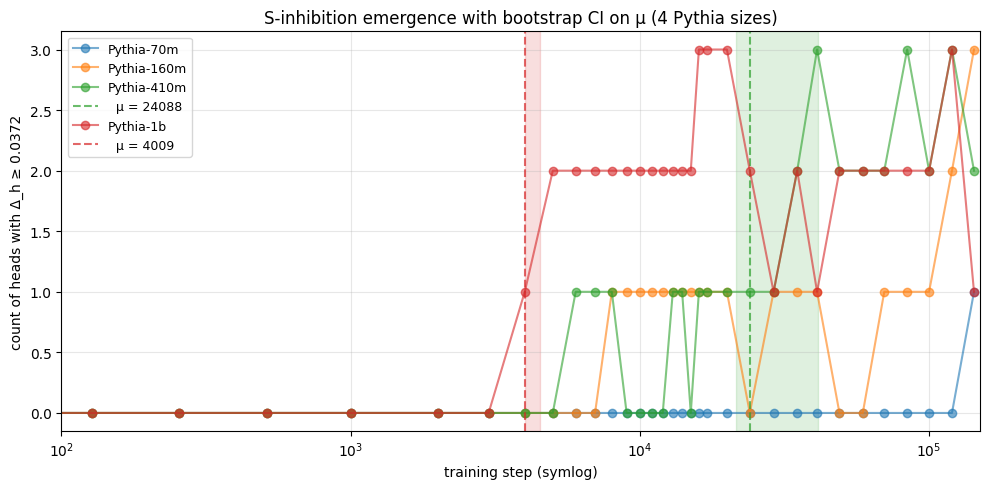

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['n_above_tau'], marker='o', alpha=0.6,
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
    bres = boots[size]
    if np.isfinite(bres.mu_point_estimate) and bres.mu_point_estimate < RIGHT_CENSOR_STEP - 1:
        ax.axvspan(bres.mu_ci_low, bres.mu_ci_high, alpha=0.15, color=SIZE_COLOR[size])
        ax.axvline(bres.mu_point_estimate, color=SIZE_COLOR[size],
                   linestyle='--', alpha=0.7,
                   label=f'  μ = {bres.mu_point_estimate:.0f}')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlim(100, 150000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel(f'count of heads with Δ_h ≥ {TAU_STRICT}')
ax.set_title('S-inhibition emergence with bootstrap CI on μ (4 Pythia sizes)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sender-head identity at final checkpoint (step143000)

Per-size enumeration of every sender (layer, head) pair passing τ_strict = 0.0372 at step143000, sorted by Δ_h. Note: the S-inhibition score is per-*sender*; the receiver NM heads are fixed by the IOI circuit definition (Wang 2022). Cross-reference with `h1c_ordering_test.ipynb` sub-deliverable 5 for cross-motif depth comparison and §S-tau for the threshold derivation.

**70m note:** if the table is empty for 70m, that is the scale-dependence finding made concrete — S-inhibition does not emerge at the smallest size during training (max_count = 1 head, right-censored at step143000).

In [6]:
rows = []
for size in SIZES:
    final = df[(df['size'] == size) & (df['step'] == 143000)]
    n_layers = int(final['layer'].max() + 1)
    passes = final[final['score'] >= TAU_STRICT].sort_values('score', ascending=False)
    if passes.empty:
        rows.append(dict(size=size, sender_layer=None, sender_head=None,
                         delta_h=float('nan'),
                         norm_depth=float('nan'),
                         note='no senders above τ_strict (S-inhibition did not emerge at this scale)'))
        continue
    for _, r in passes.iterrows():
        rows.append(dict(
            size=size,
            sender_layer=int(r['layer']), sender_head=int(r['head']),
            delta_h=float(r['score']),
            norm_depth=int(r['layer']) / max(n_layers - 1, 1),
            note='',
        ))
id_df = pd.DataFrame(rows)
print('S-inhibition sender heads at step143000, by size (sorted by Δ_h within size):')
print(id_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

S-inhibition sender heads at step143000, by size (sorted by Δ_h within size):
size  sender_layer  sender_head  delta_h  norm_depth note
 70m             4            2   0.0433      0.8000     
160m             6            2   0.0684      0.5455     
160m             8            9   0.0548      0.7273     
160m             7           10   0.0510      0.6364     
410m            12           12   0.0847      0.5217     
410m            13           13   0.0641      0.5652     
  1b             8            7   0.0692      0.5333     


## Verdict

S-inhibition full-sweep complete across 4 Pythia sizes; μ_{s,S-inhibition} extracted per (size). The S-inhibition emergence step provides the *third* term in the H1-C ordering test (registered, 3 sizes) and the (A.i)/(A.ii)/(A.iii) legs of §H3-scale (1B scale-extension); the joint verdict combining both is in `h1c_ordering_test.ipynb`.